# APIs, energias renovaveis e aprendizado de maquina

Notebook com duas tarefas independentes: classificacao da fonte renovavel e regressao da radiacao solar.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    mean_absolute_error, mean_squared_error, precision_score,
    r2_score, recall_score
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
sns.set_theme(style='whitegrid')

## 1. Classificacao da fonte renovavel

In [2]:
aneel = pd.read_csv('aneel_classificacao_orange.csv')
display(aneel.head())
print('Dimensao:', aneel.shape)
display(aneel.isna().sum().to_frame('ausentes'))
display(aneel['fonte'].value_counts().to_frame('linhas'))

,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar


Dimensao: (3876, 4)


,ausentes
potencia_kw,0
latitude,0
longitude,0
fonte,0


,linhas
fonte,
Hidráulica,1476
Solar,1200
Eólica,1200


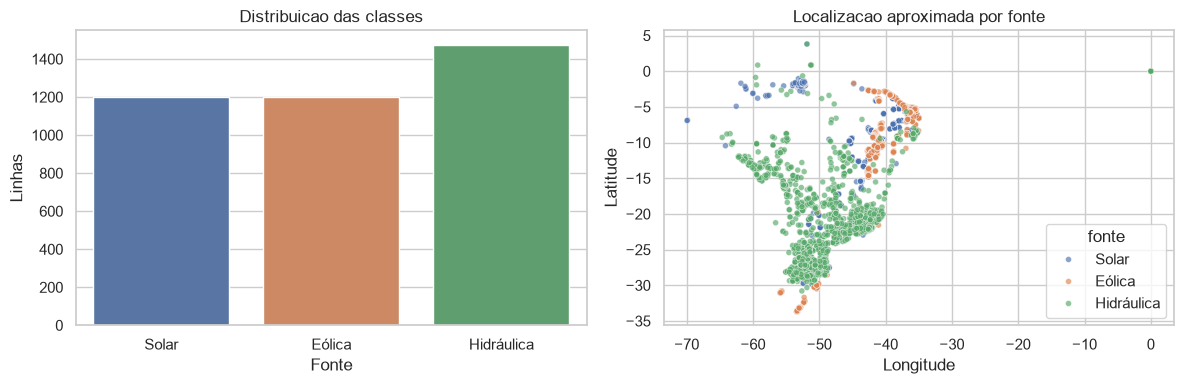

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=aneel, x='fonte', hue='fonte', legend=False, ax=axes[0])
axes[0].set_title('Distribuicao das classes')
axes[0].set_xlabel('Fonte')
axes[0].set_ylabel('Linhas')

sns.scatterplot(
    data=aneel, x='longitude', y='latitude', hue='fonte', s=18, alpha=0.65, ax=axes[1]
)
axes[1].set_title('Localizacao aproximada por fonte')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
plt.tight_layout()

In [4]:
X_cls = aneel[['potencia_kw', 'latitude', 'longitude']]
y_cls = aneel['fonte']

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=SEED, stratify=y_cls
)

classificadores = {
    'Regressao Logistica': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, random_state=SEED))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=9))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=160, max_depth=14, min_samples_leaf=3,
        random_state=SEED, n_jobs=-1
    ),
}

resultados_cls = []
previsoes_cls = {}

for nome, modelo in classificadores.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    previsoes_cls[nome] = pred
    resultados_cls.append({
        'modelo': nome,
        'accuracy': accuracy_score(y_test, pred),
        'precision_weighted': precision_score(y_test, pred, average='weighted', zero_division=0),
        'recall_weighted': recall_score(y_test, pred, average='weighted'),
        'f1_weighted': f1_score(y_test, pred, average='weighted'),
    })

resultados_cls = pd.DataFrame(resultados_cls).sort_values('f1_weighted', ascending=False)
display(resultados_cls.round(4))

,modelo,accuracy,precision_weighted,recall_weighted,f1_weighted
2,Random Forest,0.9678,0.9684,0.9678,0.9677
1,KNN,0.9601,0.9606,0.9601,0.9599
0,Regressao Logistica,0.8247,0.8313,0.8247,0.8233


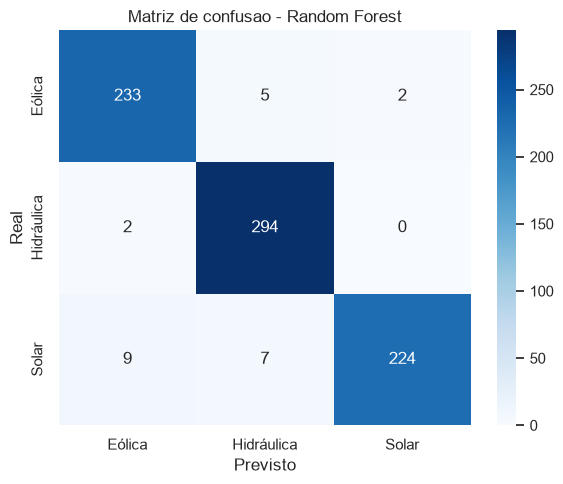

In [5]:
melhor_cls = resultados_cls.iloc[0]['modelo']
labels = sorted(y_cls.unique())
matriz = confusion_matrix(y_test, previsoes_cls[melhor_cls], labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f'Matriz de confusao - {melhor_cls}')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()

**Interpretacao.** As metricas multiclasses usam media `weighted`, adequada para o desbalanceamento das classes. A localizacao ajuda bastante porque os empreendimentos solares, eolicos e hidraulicos se concentram em regioes diferentes. Mesmo assim, potencia e coordenadas nao descrevem relevo, recurso natural, fase do empreendimento ou regra de outorga; por isso algumas classes podem ser confundidas.

## 2. Regressao da radiacao solar

In [6]:
meteo = pd.read_csv('meteo_regressao_orange.csv', parse_dates=['data_hora'])
display(meteo.head())
print('Dimensao:', meteo.shape)
display(meteo.isna().sum().to_frame('ausentes'))
display(meteo.describe().round(2))

,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01 07:00:00,25.3,74,100,17.7,7,116.0
1,2025-04-01 08:00:00,26.5,66,100,18.1,8,269.0
2,2025-04-01 09:00:00,28.4,55,97,18.0,9,529.0
3,2025-04-01 10:00:00,30.8,44,21,18.4,10,797.0
4,2025-04-01 11:00:00,32.7,36,26,20.1,11,880.0


Dimensao: (1001, 7)


,ausentes
data_hora,0
temperatura_c,0
umidade_pct,0
nuvens_pct,0
vento_kmh,0
hora,0
radiacao_w_m2,0


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001,1001.00,1001.00,1001.00,1001.00,1001.00,1001.00
mean,2025-05-16 12:00:00,28.89,50.54,55.11,15.47,12.00,472.85
min,2025-04-01 07:00:00,19.50,21.00,0.00,2.30,7.00,13.00
25%,2025-04-23 15:00:00,26.30,38.00,19.00,12.20,9.00,250.00
50%,2025-05-16 12:00:00,29.10,49.00,54.00,15.40,12.00,466.00
75%,2025-06-08 09:00:00,31.70,61.00,98.00,19.00,15.00,696.00
max,2025-06-30 17:00:00,36.10,95.00,100.00,30.10,17.00,1002.00
std,NaN,3.66,15.91,37.85,4.92,3.16,256.37


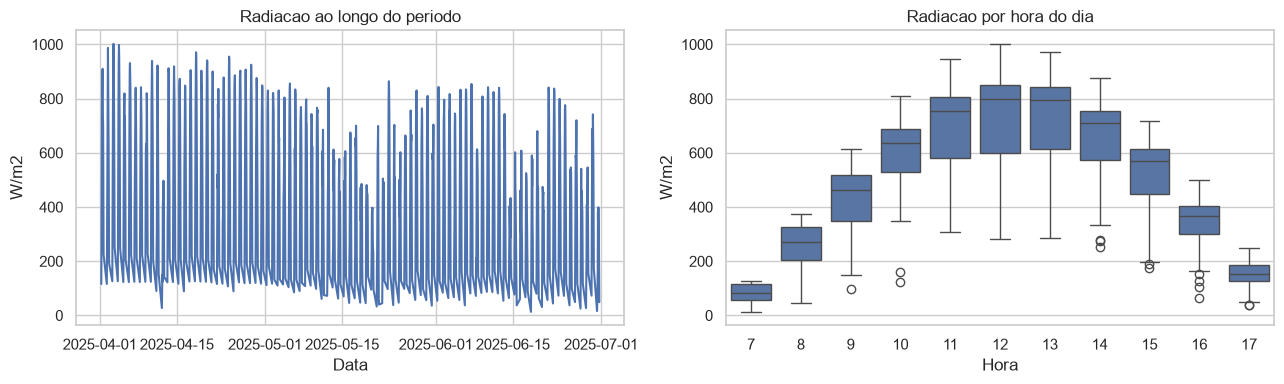

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.lineplot(data=meteo, x='data_hora', y='radiacao_w_m2', ax=axes[0])
axes[0].set_title('Radiacao ao longo do periodo')
axes[0].set_xlabel('Data')
axes[0].set_ylabel('W/m2')

sns.boxplot(data=meteo, x='hora', y='radiacao_w_m2', ax=axes[1])
axes[1].set_title('Radiacao por hora do dia')
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('W/m2')
plt.tight_layout()

In [8]:
X_reg = meteo[['temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora']]
y_reg = meteo['radiacao_w_m2']
split = int(len(meteo) * 0.8)

X_train, X_test = X_reg.iloc[:split], X_reg.iloc[split:]
y_train, y_test = y_reg.iloc[:split], y_reg.iloc[split:]

regressores = {
    'Regressao Linear': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'KNN Regressor': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsRegressor(n_neighbors=15, weights='distance'))
    ]),
    'Random Forest': RandomForestRegressor(
        n_estimators=220, max_depth=12, min_samples_leaf=2,
        random_state=SEED, n_jobs=-1
    ),
}

resultados_reg = []
previsoes_reg = pd.DataFrame({'data_hora': meteo['data_hora'].iloc[split:], 'real': y_test})

for nome, modelo in regressores.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    previsoes_reg[nome] = pred
    resultados_reg.append({
        'modelo': nome,
        'MAE': mean_absolute_error(y_test, pred),
        'MSE': mean_squared_error(y_test, pred),
        'R2': r2_score(y_test, pred),
    })

resultados_reg = pd.DataFrame(resultados_reg).sort_values('MAE')
display(resultados_reg.round(3))

,modelo,MAE,MSE,R2
2,Random Forest,67.201,7478.869,0.841
1,KNN Regressor,73.918,8344.327,0.822
0,Regressao Linear,145.205,30034.201,0.360


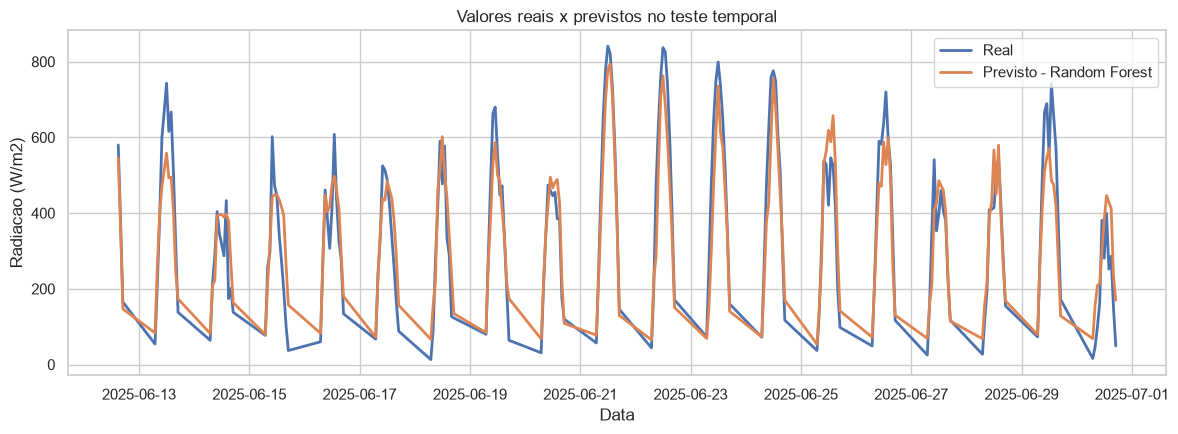

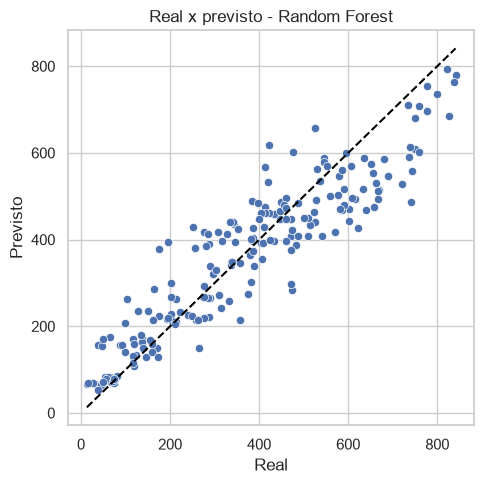

In [9]:
melhor_reg = resultados_reg.iloc[0]['modelo']

plt.figure(figsize=(12, 4.5))
plt.plot(previsoes_reg['data_hora'], previsoes_reg['real'], label='Real', linewidth=2)
plt.plot(previsoes_reg['data_hora'], previsoes_reg[melhor_reg], label=f'Previsto - {melhor_reg}', linewidth=2)
plt.title('Valores reais x previstos no teste temporal')
plt.xlabel('Data')
plt.ylabel('Radiacao (W/m2)')
plt.legend()
plt.tight_layout()

plt.figure(figsize=(5, 5))
sns.scatterplot(x=previsoes_reg['real'], y=previsoes_reg[melhor_reg], s=35)
limites = [previsoes_reg['real'].min(), previsoes_reg['real'].max()]
plt.plot(limites, limites, '--', color='black')
plt.title(f'Real x previsto - {melhor_reg}')
plt.xlabel('Real')
plt.ylabel('Previsto')
plt.tight_layout()

**Interpretacao.** A hora do dia e uma variavel central porque a radiacao segue o ciclo solar: cresce pela manha, tende ao pico perto do meio do dia e cai no fim da tarde. Estimar radiacao nao equivale a prever geracao eletrica, pois a geracao depende tambem da area dos paineis, eficiencia, inclinacao, temperatura do modulo, sombreamento, perdas eletricas e disponibilidade do sistema.